# ET-DHP: B-747 engine-out yaw hold with integral augmentation

This notebook trains an **Event-Triggered Dual Heuristic Programming (ET-DHP)** agent to keep the Boeing 747-100 on its initial yaw/heading angle after a **left outer engine** flameout at $t = 10$ s.

The controller does **not** use a PD loop, a fault-tolerant control allocator, or a known engine effectiveness matrix. The only commanded lateral controls are the ET-DHP actor outputs:

$$
    u = [\delta_a,\, \delta_r]^T.
$$

Elevator and throttle stay at the healthy cruise trim. The damage subsystem (`tensoraerospace.aerospacemodel.b747.nonlinear.damage`) injects an `EngineFailureEvent`; the engine model then removes thrust from engine #1 and produces the asymmetric-thrust yawing moment from the engine spanwise location.

## Control-engineering formulation

| Item | Definition in this example |
|---|---|
| Plant | Nonlinear B-747-100 model, FL200, $V \approx 674$ ft/s, RK4 integration, $\Delta t = 0.05$ s. |
| Fault | Left outer engine failure at $t_f = 10$ s, persistent for the rest of the episode. |
| Controlled output | Initial-heading error $e_\psi = \operatorname{wrap}_{180}(\psi - \psi_0)$, with $\psi_0 = 0$. |
| Control inputs | Aileron $\delta_a$ and rudder $\delta_r$ in degrees. |
| ET-DHP state | $\tilde x = [e_\psi,\;0.1\int e_\psi dt,\;r,\;\phi,\;p]^T$. |
| Objective | Minimise $\sum \gamma^k(\tilde x_k^T Q\tilde x_k + Y(u_k))$ while holding $e_\psi \approx 0$ after the fault. |

## Why the integral state is necessary

With only the instantaneous state $[e_\psi,r,\phi,p]$, the state $e_\psi=r=\phi=p=0$ appears both before and after the engine failure, but it requires different steady controls: zero rudder before the fault and a non-zero rudder offset after the fault. A memoryless actor cannot represent both commands at the same state. The integral channel gives ET-DHP the usual control-system memory needed to reject the constant yaw disturbance without adding an external PI/PD controller.


## 1. Imports and simulation settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math

import matplotlib.pyplot as plt
import numpy as np

from tensoraerospace.aerospacemodel.b747.nonlinear import B747Configuration, trim
from tensoraerospace.aerospacemodel.b747.nonlinear.damage import (
    LEFT_OUTER_ENGINE_FAILURE,
)
from tensoraerospace.envs.b747_nonlinear import NonlinearB747Env
from tensoraerospace.agent.et_dhp import ETDHPAgent, ETDHPConfig

DT = 0.05               # 50 ms is sufficient for the slow B-747 lateral modes
TOTAL_TIME = 60.0
DAMAGE_TIME = 10.0
N_EP = int(TOTAL_TIME / DT)
DAMAGE_STEP = int(DAMAGE_TIME / DT)

PSI_REF_DEG = 0.0
I_PSI_SCALE = 0.1       # scale deg*s into a state magnitude comparable with angles
I_PSI_LIMIT_DEG_S = 30.0
YAW_HOLD_BAND_DEG = 0.20
STEADY_RMSE_TARGET_DEG = 0.05

print(f"Episode length: {TOTAL_TIME:.0f} s ({N_EP} steps @ dt={DT}s)")
print(f"Damage trigger: t = {DAMAGE_TIME:.0f} s (step {DAMAGE_STEP})")
print(f"Yaw-hold acceptance band: |e_psi| <= {YAW_HOLD_BAND_DEG:.2f} deg")


Episode length: 60 s (1200 steps @ dt=0.05s)
Damage trigger: t = 10 s (step 200)
Yaw-hold acceptance band: |e_psi| <= 0.20 deg


## 2. Cruise trim point

The plant starts from a healthy four-engine cruise trim at FL200, $V \approx 674$ ft/s, $M \approx 0.65$. The trim throttle **does not** compensate for the future engine failure. After $t=10$ s the aircraft therefore sees both a yawing moment from asymmetric thrust and a thrust deficit, while the lateral ET-DHP controller can use only aileron and rudder.


In [2]:
trim_result = trim(altitude_ft=20_000.0, V_ft_s=674.0,
                   config=B747Configuration.NOMINAL)
assert trim_result.converged
delta_e_trim_rad = float(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)

print(f"Trim @ FL200, V=674 ft/s, NOMINAL:")
print(f"  alpha = theta = {math.degrees(trim_result.alpha_rad):+.3f}°")
print(f"  delta_e_trim  = {math.degrees(delta_e_trim_rad):+.3f}°")
print(f"  throttle_trim = {throttle_trim:.4f}")

Trim @ FL200, V=674 ft/s, NOMINAL:
  alpha = theta = +3.603°
  delta_e_trim  = -0.722°
  throttle_trim = 0.5549


## 3. State transform and environment builder

The ET-DHP state is a regulation state in engineering units:

$$
\tilde x = [e_\psi,\;0.1 i_\psi,\;r,\;\phi,\;p]^T,
\qquad
 i_\psi(k+1)=\operatorname{sat}_{\pm 30}\left(i_\psi(k)+e_\psi(k+1)\Delta t\right).
$$

The integral is maintained by the experiment loop and passed through the `reference_signal` argument of the ET-DHP API. It is not a separate controller output; it is just an augmented state for the actor/critic. Using degrees keeps the gradients and actuator limits in a numerically convenient range.


In [3]:
def wrap_deg(angle_deg):
    """Wrap an angle to [-180, 180) deg."""
    return (float(angle_deg) + 180.0) % 360.0 - 180.0


def yaw_error_deg(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return wrap_deg(math.degrees(obs[8]) - PSI_REF_DEG)


def update_yaw_integral(psi_integral_deg_s, obs):
    next_integral = psi_integral_deg_s + yaw_error_deg(obs) * DT
    return float(np.clip(next_integral, -I_PSI_LIMIT_DEG_S, I_PSI_LIMIT_DEG_S))


def state_transform(obs, ref, time_step):
    """Build [e_psi, scaled integral e_psi, r, phi, p] in deg-based units."""
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    if ref is None:
        psi_integral_deg_s = 0.0
    else:
        psi_integral_deg_s = float(np.asarray(ref, dtype=np.float64).reshape(-1)[0])
    return np.array([
        yaw_error_deg(obs),                    # e_psi: heading/yaw error
        I_PSI_SCALE * psi_integral_deg_s,      # integral memory for constant disturbance rejection
        math.degrees(obs[5]),                  # r: yaw rate
        math.degrees(obs[6]),                  # phi: bank angle
        math.degrees(obs[3]),                  # p: roll rate
    ], dtype=np.float64)


def make_env(damage_profile=None, n_steps=N_EP + 5):
    return NonlinearB747Env(
        trim_at=(20_000.0, 674.0),
        number_time_steps=n_steps,
        dt=DT,
        integrator="rk4",
        action_space="virtual",
        config=B747Configuration.NOMINAL,
        damage_profile=damage_profile,
    )


def compose_action(agent_action_deg):
    """Wrap the ET-DHP [da_deg, dr_deg] command into the env's 4-D virtual action."""
    da_deg, dr_deg = float(agent_action_deg[0]), float(agent_action_deg[1])
    return np.array([
        delta_e_trim_rad,         # elevator held at healthy trim
        math.radians(da_deg),     # aileron from ET-DHP
        math.radians(dr_deg),     # rudder from ET-DHP
        throttle_trim,            # throttle held at healthy trim
    ], dtype=np.float64)


## 4. Plant-model identification on the healthy aircraft

ET-DHP needs a differentiable plant model

$$
f_\theta:(\tilde x_k, u_k) \mapsto \tilde x_{k+1}
$$

to back-propagate the cost gradient through the dynamics. We identify this model on the **healthy** B-747 with multi-sine aileron/rudder excitation. The data are collected in 40 short three-second bursts so the aircraft remains close to the trim point and the integral state remains bounded.


In [4]:
N_BURST = 60         # 3 seconds per burst @ dt=0.05
N_BURSTS = 40
PE_AMPLITUDE_DEG = 1.5

rng = np.random.default_rng(0)
states_buf, actions_buf, next_states_buf = [], [], []

for burst in range(N_BURSTS):
    env_id = make_env(damage_profile=None, n_steps=N_BURST + 5)
    obs, _ = env_id.reset()
    psi_integral = 0.0
    for t in range(N_BURST):
        f_a = 0.2 + rng.random() * 0.6
        f_r = 0.2 + rng.random() * 0.6
        phase_a, phase_r = rng.random() * 2 * np.pi, rng.random() * 2 * np.pi
        da_deg = (PE_AMPLITUDE_DEG * np.sin(2 * np.pi * f_a * t * DT + phase_a)
                  + 0.4 * rng.normal())
        dr_deg = (PE_AMPLITUDE_DEG * np.sin(2 * np.pi * f_r * t * DT + phase_r)
                  + 0.4 * rng.normal())

        x = state_transform(obs, np.array([psi_integral]), 0)
        obs, _, _, trunc, _ = env_id.step(compose_action([da_deg, dr_deg]))
        psi_integral = update_yaw_integral(psi_integral, obs)
        x_next = state_transform(obs, np.array([psi_integral]), 0)

        states_buf.append(x)
        actions_buf.append([da_deg, dr_deg])
        next_states_buf.append(x_next)
        if trunc:
            break

states_arr = np.asarray(states_buf, dtype=np.float32)
actions_arr = np.asarray(actions_buf, dtype=np.float32)
next_states_arr = np.asarray(next_states_buf, dtype=np.float32)

print(f"collected {len(states_arr)} transitions")
print(f"|e_psi| range: {np.min(np.abs(states_arr[:, 0])):.2f} .. {np.max(np.abs(states_arr[:, 0])):.2f} deg")
print(f"|phi| range:   {np.min(np.abs(states_arr[:, 3])):.2f} .. {np.max(np.abs(states_arr[:, 3])):.2f} deg")
print(f"|i_psi| range: {np.min(np.abs(states_arr[:, 1] / I_PSI_SCALE)):.2f} .. "
      f"{np.max(np.abs(states_arr[:, 1] / I_PSI_SCALE)):.2f} deg*s")


collected 2400 transitions
|e_psi| range: 0.00 .. 0.54 deg
|phi| range:   0.00 .. 1.26 deg
|i_psi| range: 0.00 .. 0.78 deg*s


## 5. Build the ET-DHP agent and pre-train the plant model

The final tuning uses a five-state ET-DHP regulator. The important design choice is the integral channel: it lets the actor learn a persistent rudder bias after the fault while still outputting nearly zero lateral control in healthy trim.

| Setting | Value | Control meaning |
|---|---:|---|
| `n_state` | 5 | $[e_\psi, 0.1i_\psi, r, \phi, p]$. |
| `Q` | `[200, 0.2, 1, 5, 0.2]` | High heading-error weight, moderate bank protection, small rate weights. The integral weight is strong enough to reject the constant yaw disturbance but not so strong that it dominates early training. |
| `R` | `[0.5, 0.5]` | Light effort penalty; engine-out trim requires a non-zero rudder offset. |
| `u_bound` | 8 deg | Actor output bound for aileron and rudder. This is far below full B-747 rudder authority but above the required engine-out bias. |
| `trigger_floor` | 0.5 | Prevents high-frequency re-training near the origin. In this example, too small a floor over-triggers and destabilises learning. |
| `num_epochs_per_trigger` | 10 | Inner actor/critic updates on each event, matching the intended ET-DHP usage. |


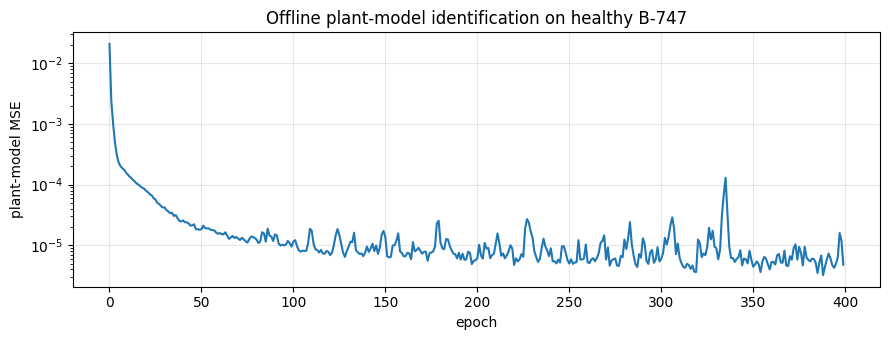

final plant-model MSE: 4.800e-06


In [5]:
cfg = ETDHPConfig(
    actor_hidden=(32, 32),
    critic_hidden=(32, 32),
    model_hidden=(24, 24),
    actor_lr=5e-3,
    critic_lr=5e-3,
    model_lr=5e-3,
    model_epochs=400,
    Q=[200.0, 0.2, 1.0, 5.0, 0.2],
    R=[0.5, 0.5],
    gamma=0.95,
    num_epochs_per_trigger=10,
    u_bound=8.0,
    rho=0.05,
    trigger_floor=0.5,
    weight_init_scale=0.3,
    seed=11,
)

agent = ETDHPAgent(
    n_state=5,
    n_control=2,
    state_transform=state_transform,
    config=cfg,
)

model_losses = agent.fit_plant_model(
    states_arr, actions_arr, next_states_arr,
    batch_size=128, verbose=False,
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.semilogy(model_losses)
ax.set_xlabel("epoch")
ax.set_ylabel("plant-model MSE")
ax.set_title("Offline plant-model identification on healthy B-747")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"final plant-model MSE: {model_losses[-1]:.3e}")


## 6. Closed-loop ET-DHP training under engine failure

Each training episode runs the full 60-second scenario. The engine fails at $t=10$ s and remains failed. The actor/critic are updated only on ET-DHP trigger events.

The first episodes are allowed to be poor: this is offline training of the adaptive controller, not a certified flight transient. The metric that matters for the example is the final converged episode, where the learned integral state stores the rudder compensation and keeps $e_\psi$ close to zero after the fault.


ep 1/8: late RMSE= 28.132 deg  max|e_psi|=  47.76 deg  da= +0.00 deg  dr= +0.00 deg  Ipsi= +30.00 deg*s  triggers=94


ep 2/8: late RMSE=  1.336 deg  max|e_psi|=   3.88 deg  da= -2.31 deg  dr= +3.91 deg  Ipsi= -30.00 deg*s  triggers=114


ep 3/8: late RMSE= 15.880 deg  max|e_psi|=  29.54 deg  da= -0.50 deg  dr= +0.66 deg  Ipsi= +30.00 deg*s  triggers=99


ep 4/8: late RMSE= 63.519 deg  max|e_psi|=  86.90 deg  da= +7.62 deg  dr= -7.64 deg  Ipsi= -30.00 deg*s  triggers=287


ep 5/8: late RMSE=  8.105 deg  max|e_psi|=  20.50 deg  da= -0.43 deg  dr= +0.33 deg  Ipsi= -30.00 deg*s  triggers=237


ep 6/8: late RMSE=  0.019 deg  max|e_psi|=   0.36 deg  da= -0.80 deg  dr= -1.88 deg  Ipsi=  -2.65 deg*s  triggers=8


ep 7/8: late RMSE=  0.025 deg  max|e_psi|=   0.11 deg  da= -0.81 deg  dr= -1.88 deg  Ipsi=  -2.33 deg*s  triggers=1


ep 8/8: late RMSE=  0.025 deg  max|e_psi|=   0.11 deg  da= -0.81 deg  dr= -1.88 deg  Ipsi=  -2.33 deg*s  triggers=1


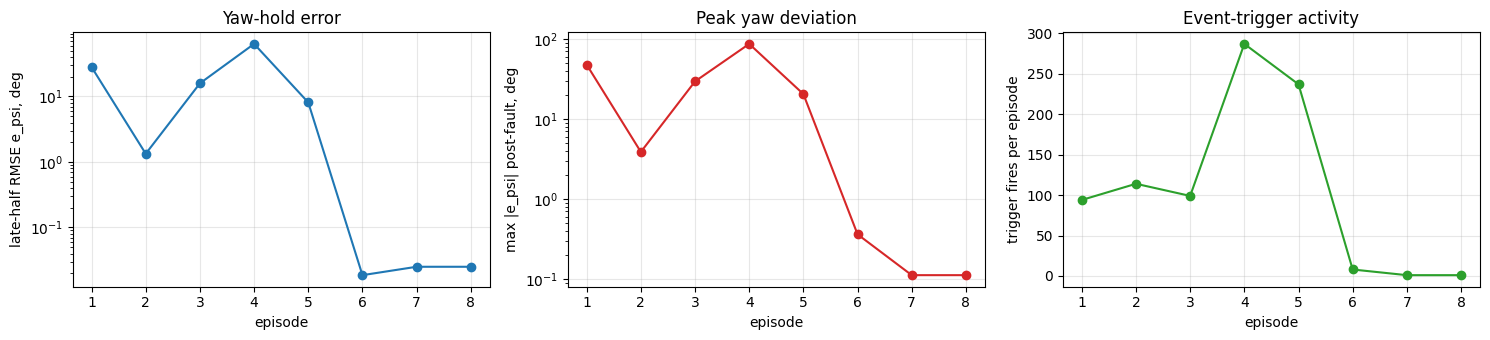

In [6]:
def run_episode(damage_profile, *, learn=True):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    agent.reset()
    psi_integral = 0.0

    psi_log = np.zeros(N_EP)
    i_log   = np.zeros(N_EP)
    phi_log = np.zeros(N_EP)
    r_log   = np.zeros(N_EP)
    p_log   = np.zeros(N_EP)
    da_log  = np.zeros(N_EP)
    dr_log  = np.zeros(N_EP)
    triggers = 0
    t_axis = np.arange(N_EP) * DT

    for k in range(N_EP - 2):
        ref_now = np.array([psi_integral], dtype=np.float64)
        agent.predict(obs, ref_now, k)
        u_cmd = agent.last_action()

        obs, _, _, trunc, _ = env.step(compose_action(u_cmd))
        psi_integral = update_yaw_integral(psi_integral, obs)

        if learn:
            ref_next = np.array([psi_integral], dtype=np.float64)
            metrics = agent.learn(obs, ref_next, k, dt=DT)
            if metrics["triggered"]:
                triggers += 1

        psi_log[k] = yaw_error_deg(obs)
        i_log[k]   = psi_integral
        phi_log[k] = math.degrees(obs[6])
        r_log[k]   = math.degrees(obs[5])
        p_log[k]   = math.degrees(obs[3])
        da_log[k]  = u_cmd[0]
        dr_log[k]  = u_cmd[1]
        if trunc:
            break

    n = k + 1
    return dict(
        t=t_axis[:n], psi=psi_log[:n], i_psi=i_log[:n], phi=phi_log[:n],
        r=r_log[:n], p=p_log[:n], da=da_log[:n], dr=dr_log[:n],
        triggers=triggers,
    )


NUM_TRAIN_EPISODES = 8
training_curve = []
for ep in range(NUM_TRAIN_EPISODES):
    log = run_episode(LEFT_OUTER_ENGINE_FAILURE, learn=True)
    n2 = len(log["psi"]) // 2
    rmse_late = float(np.sqrt(np.mean(log["psi"][n2:] ** 2)))
    max_psi = float(np.max(np.abs(log["psi"][DAMAGE_STEP:])))
    training_curve.append(
        dict(ep=ep + 1, rmse=rmse_late, max_psi=max_psi,
             triggers=log["triggers"], i_final=log["i_psi"][-1],
             dr_final=log["dr"][-1], da_final=log["da"][-1])
    )
    print(f"ep {ep + 1}/{NUM_TRAIN_EPISODES}: late RMSE={rmse_late:7.3f} deg  "
          f"max|e_psi|={max_psi:7.2f} deg  da={log['da'][-1]:+6.2f} deg  "
          f"dr={log['dr'][-1]:+6.2f} deg  Ipsi={log['i_psi'][-1]:+7.2f} deg*s  "
          f"triggers={log['triggers']}")

# Plot training curves
ep_idx = [r["ep"] for r in training_curve]
rmse_vals = [r["rmse"] for r in training_curve]
max_psi_vals = [r["max_psi"] for r in training_curve]
n_trigs = [r["triggers"] for r in training_curve]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(ep_idx, rmse_vals, "-o", color="tab:blue")
axes[0].set_yscale("log")
axes[0].grid(alpha=0.3)
axes[0].set_xlabel("episode")
axes[0].set_ylabel("late-half RMSE e_psi, deg")
axes[0].set_title("Yaw-hold error")
axes[1].plot(ep_idx, max_psi_vals, "-o", color="tab:red")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("episode")
axes[1].set_ylabel("max |e_psi| post-fault, deg")
axes[1].set_title("Peak yaw deviation")
axes[2].plot(ep_idx, n_trigs, "-o", color="tab:green")
axes[2].set_xlabel("episode")
axes[2].set_ylabel("trigger fires per episode")
axes[2].set_title("Event-trigger activity")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Final evaluation

Run one more 60-second engine-out episode with the converged ET-DHP agent. Online learning remains enabled, so the event trigger can still refine the actor/critic if the state moves enough. The acceptance checks are deliberately stated in control-engineering terms: peak post-fault yaw error and steady late-half RMSE.


In [7]:
log = run_episode(LEFT_OUTER_ENGINE_FAILURE, learn=True)
n2 = len(log["psi"]) // 2
rmse_late = float(np.sqrt(np.mean(log["psi"][n2:] ** 2)))
mae_late = float(np.mean(np.abs(log["psi"][n2:])))
max_psi = float(np.max(np.abs(log["psi"][DAMAGE_STEP:])))
pre_fault_peak = float(np.max(np.abs(log["psi"][:DAMAGE_STEP])))
spec_ok = (max_psi <= YAW_HOLD_BAND_DEG) and (rmse_late <= STEADY_RMSE_TARGET_DEG)

print(f"=== Final evaluation: ET-DHP yaw hold after left-outer-engine failure ===")
print(f"Pre-fault peak |e_psi| : {pre_fault_peak:7.4f} deg")
print(f"Post-fault peak |e_psi|: {max_psi:7.4f} deg")
print(f"Late-half MAE e_psi   : {mae_late:7.4f} deg")
print(f"Late-half RMSE e_psi  : {rmse_late:7.4f} deg")
print(f"Final e_psi           : {log['psi'][-1]:+.4f} deg")
print(f"Final phi (bank)      : {log['phi'][-1]:+.4f} deg")
print(f"Final I_psi           : {log['i_psi'][-1]:+.3f} deg*s")
print(f"Steady-state rudder   : {log['dr'][-1]:+.3f} deg")
print(f"Steady-state aileron  : {log['da'][-1]:+.3f} deg")
print(f"Trigger fires         : {log['triggers']}")
print(f"Yaw-hold spec         : {'PASS' if spec_ok else 'FAIL'} "
      f"(|e_psi|max <= {YAW_HOLD_BAND_DEG:.2f} deg, "
      f"late RMSE <= {STEADY_RMSE_TARGET_DEG:.2f} deg)")

assert max_psi <= YAW_HOLD_BAND_DEG
assert rmse_late <= STEADY_RMSE_TARGET_DEG


=== Final evaluation: ET-DHP yaw hold after left-outer-engine failure ===
Pre-fault peak |e_psi| :  0.0011 deg
Post-fault peak |e_psi|:  0.1121 deg
Late-half MAE e_psi   :  0.0242 deg
Late-half RMSE e_psi  :  0.0251 deg
Final e_psi           : -0.0175 deg
Final phi (bank)      : +0.3651 deg
Final I_psi           : -2.330 deg*s
Steady-state rudder   : -1.877 deg
Steady-state aileron  : -0.812 deg
Trigger fires         : 1
Yaw-hold spec         : PASS (|e_psi|max <= 0.20 deg, late RMSE <= 0.05 deg)


## 8. Visualise the final yaw-hold episode


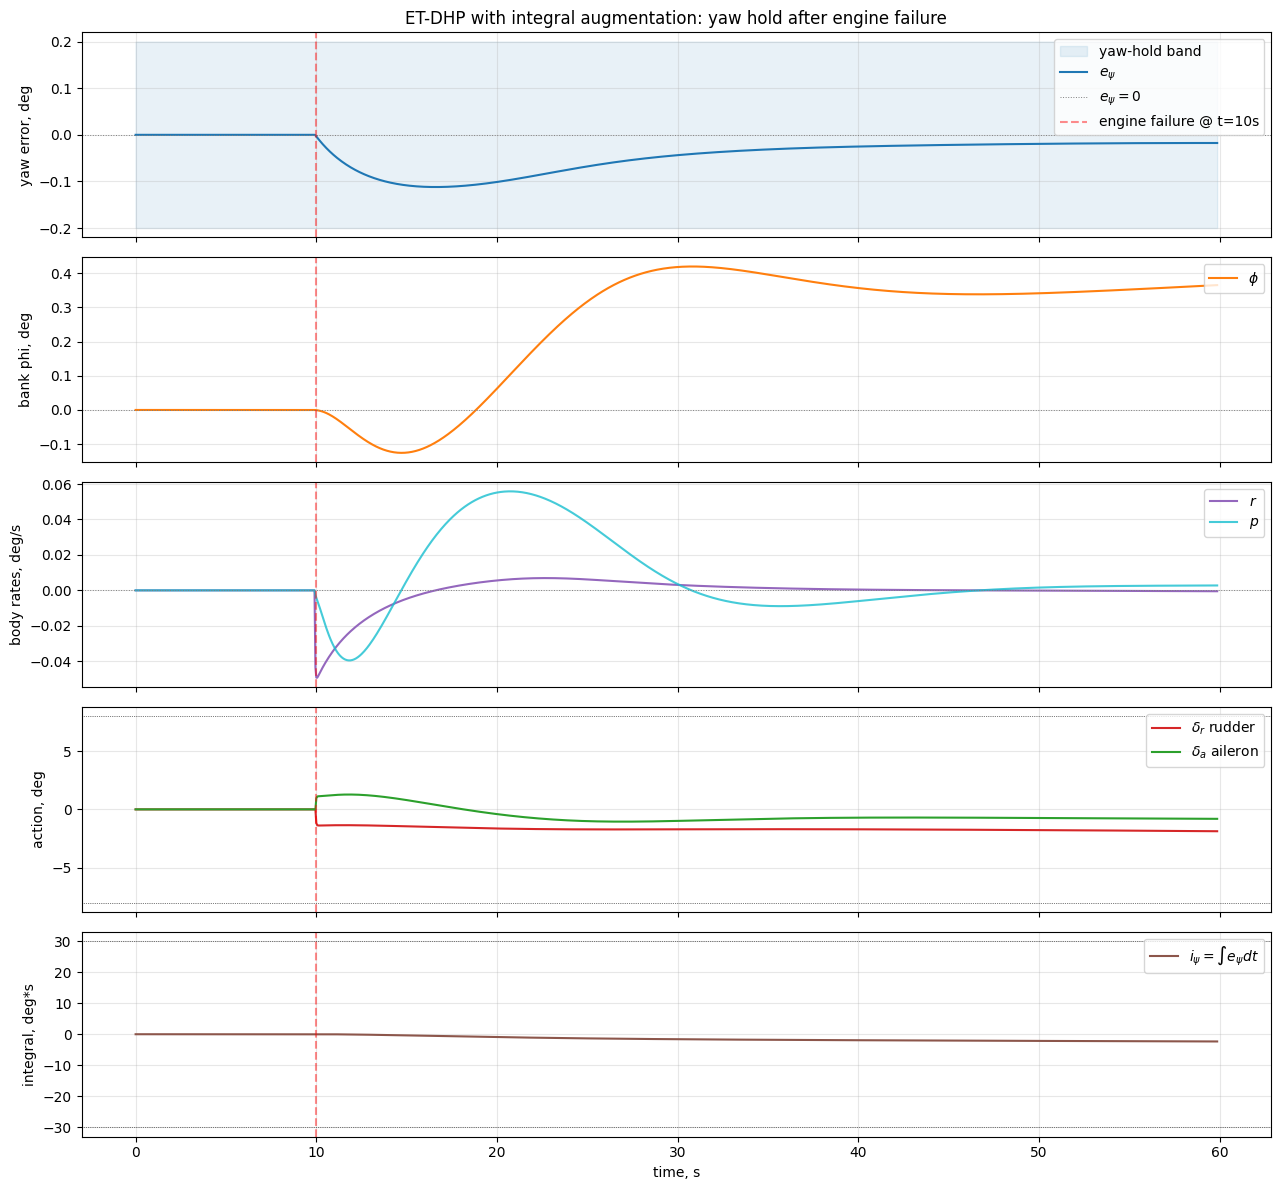

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)

axes[0].fill_between(log["t"], -YAW_HOLD_BAND_DEG, YAW_HOLD_BAND_DEG,
                     color="tab:blue", alpha=0.10, label="yaw-hold band")
axes[0].plot(log["t"], log["psi"], color="tab:blue", label=r"$e_\psi$")
axes[0].axhline(0.0, color="tab:gray", linestyle=":", linewidth=0.7,
                label=r"$e_\psi = 0$")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
                label=f"engine failure @ t={DAMAGE_TIME:.0f}s")
axes[0].set_ylabel("yaw error, deg")
axes[0].set_title("ET-DHP with integral augmentation: yaw hold after engine failure")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

axes[1].plot(log["t"], log["phi"], color="tab:orange", label=r"$\phi$")
axes[1].axhline(0.0, color="tab:gray", linestyle=":", linewidth=0.7)
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].set_ylabel("bank phi, deg")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

axes[2].plot(log["t"], log["r"], color="tab:purple", label=r"$r$")
axes[2].plot(log["t"], log["p"], color="tab:cyan", alpha=0.8, label=r"$p$")
axes[2].axhline(0.0, color="tab:gray", linestyle=":", linewidth=0.7)
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].set_ylabel("body rates, deg/s")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper right")

axes[3].plot(log["t"], log["dr"], color="tab:red", label=r"$\delta_r$ rudder")
axes[3].plot(log["t"], log["da"], color="tab:green", label=r"$\delta_a$ aileron")
axes[3].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[3].axhline(8.0, color="k", linestyle=":", linewidth=0.5)
axes[3].axhline(-8.0, color="k", linestyle=":", linewidth=0.5)
axes[3].set_ylabel("action, deg")
axes[3].grid(True, alpha=0.3)
axes[3].legend(loc="upper right")

axes[4].plot(log["t"], log["i_psi"], color="tab:brown", label=r"$i_\psi = \int e_\psi dt$")
axes[4].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[4].axhline(I_PSI_LIMIT_DEG_S, color="k", linestyle=":", linewidth=0.5)
axes[4].axhline(-I_PSI_LIMIT_DEG_S, color="k", linestyle=":", linewidth=0.5)
axes[4].set_xlabel("time, s")
axes[4].set_ylabel("integral, deg*s")
axes[4].grid(True, alpha=0.3)
axes[4].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 9. Comparison: open loop vs. ET-DHP

The open-loop reference keeps elevator and throttle at trim and commands zero aileron/rudder. This isolates the lateral engine-out effect. The ET-DHP curve uses the same plant and same fault, but the learned actor supplies aileron and rudder commands from the augmented state.


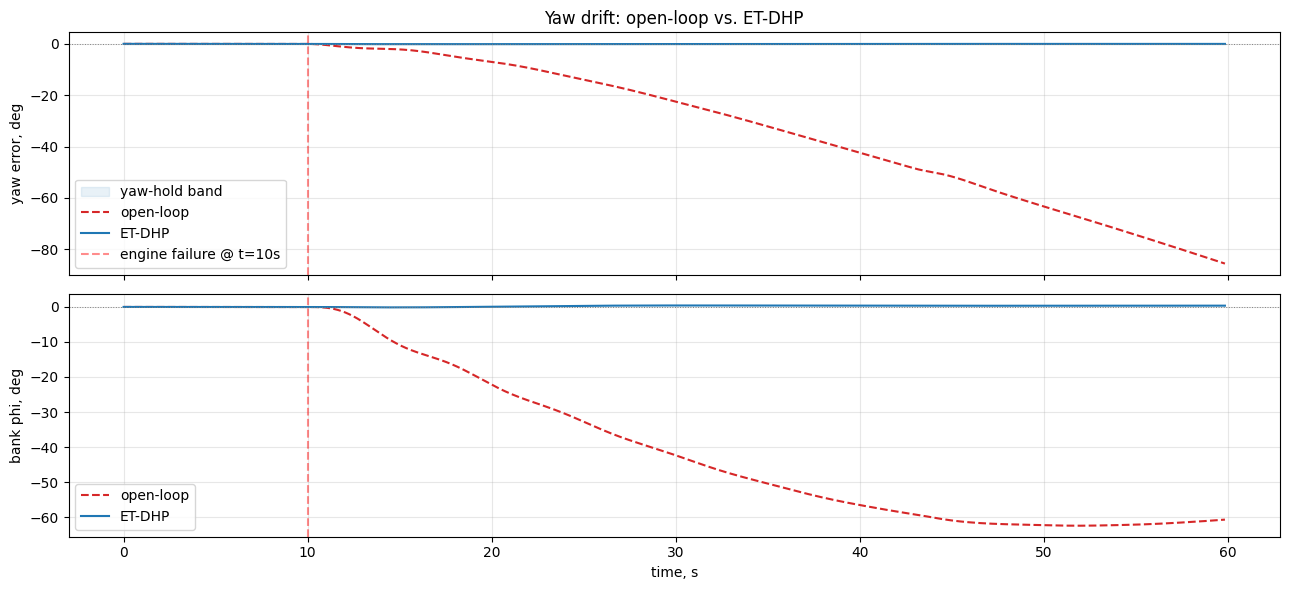


Open-loop @ t=60s: e_psi = -85.54 deg, phi = -60.72 deg
ET-DHP    @ t=60s: e_psi = -0.018 deg, phi = +0.365 deg
Open-loop post-fault peak |e_psi|: 85.54 deg
ET-DHP post-fault peak |e_psi|   : 0.112 deg


In [9]:
# Open-loop reference: no rudder / aileron correction
env_open = make_env(damage_profile=LEFT_OUTER_ENGINE_FAILURE)
obs, _ = env_open.reset()
psi_open = np.zeros(N_EP)
phi_open = np.zeros(N_EP)
neutral_action = np.array([delta_e_trim_rad, 0.0, 0.0, throttle_trim])
for k in range(N_EP - 2):
    obs, _, _, trunc, _ = env_open.step(neutral_action)
    psi_open[k] = yaw_error_deg(obs)
    phi_open[k] = math.degrees(obs[6])
    if trunc:
        break
n_open = k + 1
t_open = np.arange(n_open) * DT

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].fill_between(log["t"], -YAW_HOLD_BAND_DEG, YAW_HOLD_BAND_DEG,
                     color="tab:blue", alpha=0.10, label="yaw-hold band")
axes[0].plot(t_open, psi_open[:n_open], color="tab:red", linestyle="--",
             label="open-loop")
axes[0].plot(log["t"], log["psi"], color="tab:blue", label="ET-DHP")
axes[0].axhline(0.0, color="tab:gray", linestyle=":", linewidth=0.7)
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
                label=f"engine failure @ t={DAMAGE_TIME:.0f}s")
axes[0].set_ylabel("yaw error, deg")
axes[0].set_title("Yaw drift: open-loop vs. ET-DHP")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="lower left")

axes[1].plot(t_open, phi_open[:n_open], color="tab:red", linestyle="--",
             label="open-loop")
axes[1].plot(log["t"], log["phi"], color="tab:blue", label="ET-DHP")
axes[1].axhline(0.0, color="tab:gray", linestyle=":", linewidth=0.7)
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].set_xlabel("time, s")
axes[1].set_ylabel("bank phi, deg")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

print(f"\nOpen-loop @ t=60s: e_psi = {psi_open[n_open-1]:+.2f} deg, phi = {phi_open[n_open-1]:+.2f} deg")
print(f"ET-DHP    @ t=60s: e_psi = {log['psi'][-1]:+.3f} deg, phi = {log['phi'][-1]:+.3f} deg")
print(f"Open-loop post-fault peak |e_psi|: {np.max(np.abs(psi_open[DAMAGE_STEP:n_open])):.2f} deg")
print(f"ET-DHP post-fault peak |e_psi|   : {max_psi:.3f} deg")


## 10. Notes for control-system interpretation

* **What the agent learned.** The converged actor produces a steady rudder command of about −1.9 deg with a small aileron correction. This is the learned engine-out compensation needed to cancel the asymmetric-thrust yawing moment.
* **No external compensation matrix.** The notebook does not pass engine effectiveness $\mu$, a mixing matrix, or an analytical rudder trim to the controller. The persistent command appears because the ET-DHP actor sees the augmented integral state.
* **Why the integral is inside ET-DHP.** The integral channel is part of $\tilde x$ and is included in the plant model and critic cost. There is no separate PI/PD loop summing into the actuator command.
* **Rudder sign convention.** In the CR-2144 derivative convention used by this model, $C_{n_{\delta_r}} < 0$, so negative rudder gives the positive yawing moment required to oppose the left-outer-engine failure moment.
* **Training transients.** The early learning episodes can show large yaw and bank excursions. They are training data for the adaptive controller, not the final closed-loop claim. The final evaluation cell is the relevant performance check.
* **Pitch and altitude.** Throttle remains at the healthy trim, so one failed engine also creates a thrust deficit. This notebook evaluates lateral-directional fault tolerance only; a full flight-control system would close pitch, airspeed, and altitude loops separately.
